# Image-Based Gender Classification using Convolutional NeuralNetworks

**Goal:** Classify face images as male or female using a Convolutional Neural Network.

**Pipeline:** load and preprocess images (OpenCV) → resize/normalize → build CNN (Conv2D + MaxPooling) → train → evaluate.

> Requires the `Female/` and `Male/` image folders at the paths set in the same folder — update 'path' of female and male according to your local paths before running.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [ ]:
path_female = "D:/DATASETS/Gender/Female/"

In [ ]:
path_female

'D:/DATASETS/Gender/Female/'

In [ ]:
path_male = "D:/DATASETS/Gender/Male/"

In [ ]:
path_male

'D:/DATASETS/Gender/Male/'

In [ ]:
os.listdir(path_female)

['131507.jpg.jpg',
 '131508.jpg.jpg',
 '131509.jpg.jpg',
 '131511.jpg.jpg',
 '131513.jpg.jpg',
 '131515.jpg.jpg',
 '131516.jpg.jpg',
 '131517.jpg.jpg',
 '131521.jpg.jpg',
 '131523.jpg.jpg',
 '131527.jpg.jpg',
 '131529.jpg.jpg',
 '131530.jpg.jpg',
 '131531.jpg.jpg',
 '131537.jpg.jpg',
 '131541.jpg.jpg',
 '131544.jpg.jpg',
 '131546.jpg.jpg',
 '131547.jpg.jpg',
 '131551.jpg.jpg',
 '131552.jpg.jpg',
 '131554.jpg.jpg',
 '131556.jpg.jpg',
 '131564.jpg.jpg',
 '131571.jpg.jpg',
 '131572.jpg.jpg',
 '131573.jpg.jpg',
 '131576.jpg.jpg',
 '131578.jpg.jpg',
 '131579.jpg.jpg',
 '131583.jpg.jpg',
 '131585.jpg.jpg',
 '131588.jpg.jpg',
 '131601.jpg.jpg',
 '131605.jpg.jpg',
 '131608.jpg.jpg',
 '131617.jpg.jpg',
 '131623.jpg.jpg',
 '131630.jpg.jpg',
 '131634.jpg.jpg',
 '131643.jpg.jpg',
 '131651.jpg.jpg',
 '131652.jpg.jpg',
 '131653.jpg.jpg',
 '131654.jpg.jpg',
 '131662.jpg.jpg',
 '131668.jpg.jpg',
 '131669.jpg.jpg',
 '131671.jpg.jpg',
 '131675.jpg.jpg',
 '131677.jpg.jpg',
 '131682.jpg.jpg',
 '131686.jpg

In [ ]:
female_image_names = os.listdir(path_female)

In [ ]:
len(female_image_names)

5000

In [ ]:
female_image_names

['131507.jpg.jpg',
 '131508.jpg.jpg',
 '131509.jpg.jpg',
 '131511.jpg.jpg',
 '131513.jpg.jpg',
 '131515.jpg.jpg',
 '131516.jpg.jpg',
 '131517.jpg.jpg',
 '131521.jpg.jpg',
 '131523.jpg.jpg',
 '131527.jpg.jpg',
 '131529.jpg.jpg',
 '131530.jpg.jpg',
 '131531.jpg.jpg',
 '131537.jpg.jpg',
 '131541.jpg.jpg',
 '131544.jpg.jpg',
 '131546.jpg.jpg',
 '131547.jpg.jpg',
 '131551.jpg.jpg',
 '131552.jpg.jpg',
 '131554.jpg.jpg',
 '131556.jpg.jpg',
 '131564.jpg.jpg',
 '131571.jpg.jpg',
 '131572.jpg.jpg',
 '131573.jpg.jpg',
 '131576.jpg.jpg',
 '131578.jpg.jpg',
 '131579.jpg.jpg',
 '131583.jpg.jpg',
 '131585.jpg.jpg',
 '131588.jpg.jpg',
 '131601.jpg.jpg',
 '131605.jpg.jpg',
 '131608.jpg.jpg',
 '131617.jpg.jpg',
 '131623.jpg.jpg',
 '131630.jpg.jpg',
 '131634.jpg.jpg',
 '131643.jpg.jpg',
 '131651.jpg.jpg',
 '131652.jpg.jpg',
 '131653.jpg.jpg',
 '131654.jpg.jpg',
 '131662.jpg.jpg',
 '131668.jpg.jpg',
 '131669.jpg.jpg',
 '131671.jpg.jpg',
 '131675.jpg.jpg',
 '131677.jpg.jpg',
 '131682.jpg.jpg',
 '131686.jpg

In [ ]:
type(female_image_names)

list

In [ ]:
female_image_names[0]

'131507.jpg.jpg'

In [ ]:
female_image_names[1]

'131508.jpg.jpg'

In [ ]:
path_female

'D:/DATASETS/Gender/Female/'

In [ ]:
path_female+female_image_names[9]

'D:/DATASETS/Gender/Female/131523.jpg.jpg'

In [ ]:
path_female+female_image_names[21]

'D:/DATASETS/Gender/Female/131554.jpg.jpg'

In [ ]:
cv2.imread(path_female+female_image_names[21])

array([[[ 34,  89, 126],
        [ 33,  88, 125],
        [ 56, 114, 150],
        ...,
        [ 12,  55,  94],
        [ 35,  74, 112],
        [ 40,  79, 117]],

       [[ 25,  80, 117],
        [ 41,  96, 133],
        [ 52, 110, 146],
        ...,
        [ 47,  90, 129],
        [ 13,  54,  93],
        [ 38,  80, 117]],

       [[ 45, 100, 137],
        [ 62, 117, 154],
        [ 58, 116, 152],
        ...,
        [ 70, 115, 153],
        [ 15,  58,  97],
        [ 28,  71, 110]],

       ...,

       [[ 10,  47,  97],
        [ 29,  67, 115],
        [  7,  45,  93],
        ...,
        [ 51, 105, 158],
        [ 41,  94, 145],
        [ 26,  79, 130]],

       [[ 23,  59, 107],
        [ 24,  60, 108],
        [  0,  28,  74],
        ...,
        [ 40,  93, 144],
        [ 38,  88, 140],
        [ 21,  71, 123]],

       [[ 14,  47,  96],
        [ 26,  60, 106],
        [  5,  39,  85],
        ...,
        [ 38,  88, 140],
        [ 28,  76, 128],
        [ 12,  60, 112]]

In [ ]:
female1 = cv2.imread(path_female+female_image_names[21])

In [ ]:
female1

array([[[ 34,  89, 126],
        [ 33,  88, 125],
        [ 56, 114, 150],
        ...,
        [ 12,  55,  94],
        [ 35,  74, 112],
        [ 40,  79, 117]],

       [[ 25,  80, 117],
        [ 41,  96, 133],
        [ 52, 110, 146],
        ...,
        [ 47,  90, 129],
        [ 13,  54,  93],
        [ 38,  80, 117]],

       [[ 45, 100, 137],
        [ 62, 117, 154],
        [ 58, 116, 152],
        ...,
        [ 70, 115, 153],
        [ 15,  58,  97],
        [ 28,  71, 110]],

       ...,

       [[ 10,  47,  97],
        [ 29,  67, 115],
        [  7,  45,  93],
        ...,
        [ 51, 105, 158],
        [ 41,  94, 145],
        [ 26,  79, 130]],

       [[ 23,  59, 107],
        [ 24,  60, 108],
        [  0,  28,  74],
        ...,
        [ 40,  93, 144],
        [ 38,  88, 140],
        [ 21,  71, 123]],

       [[ 14,  47,  96],
        [ 26,  60, 106],
        [  5,  39,  85],
        ...,
        [ 38,  88, 140],
        [ 28,  76, 128],
        [ 12,  60, 112]]

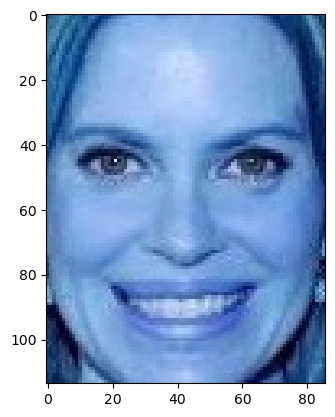

In [ ]:
plt.imshow(female1)

In [ ]:
female2 = cv2.imread(path_female+female_image_names[28])

In [ ]:
female2

array([[[  3,   4,   2],
        [  0,   2,   2],
        [  0,   3,   4],
        ...,
        [ 17,  25,  54],
        [ 17,  26,  53],
        [ 14,  18,  46]],

       [[  4,   5,   3],
        [  1,   3,   3],
        [  0,   3,   4],
        ...,
        [ 22,  30,  59],
        [ 21,  30,  57],
        [ 17,  21,  49]],

       [[  6,   4,   3],
        [  4,   4,   4],
        [  1,   3,   4],
        ...,
        [ 27,  35,  64],
        [ 25,  34,  61],
        [ 21,  25,  53]],

       ...,

       [[ 21, 144, 104],
        [ 24, 147, 107],
        [ 26, 148, 110],
        ...,
        [ 29,  63, 117],
        [ 13,  45,  98],
        [  8,  39,  92]],

       [[ 26, 149, 109],
        [ 22, 145, 105],
        [ 26, 148, 110],
        ...,
        [ 32,  65, 121],
        [  9,  43,  97],
        [  7,  37,  92]],

       [[ 26, 149, 109],
        [ 17, 140, 100],
        [ 22, 144, 106],
        ...,
        [ 34,  66, 125],
        [  9,  42,  98],
        [  8,  37,  94]]

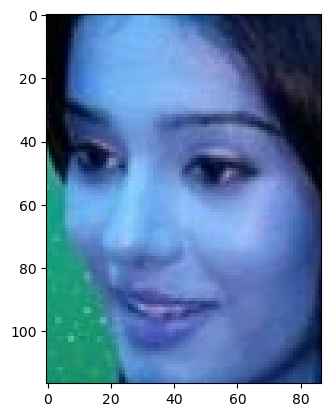

In [ ]:
plt.imshow(female2)

In [ ]:
female1.shape

(114, 86, 3)

In [ ]:
female2.shape

(117, 87, 3)

### Male Images

In [ ]:
path_male

'D:/DATASETS/Gender/Male/'

In [ ]:
os.listdir(path_male)

['091279.jpg.jpg',
 '091280.jpg.jpg',
 '091281.jpg.jpg',
 '091283.jpg.jpg',
 '091286.jpg.jpg',
 '091290.jpg.jpg',
 '091291.jpg.jpg',
 '091304.jpg.jpg',
 '091305.jpg.jpg',
 '091313.jpg.jpg',
 '091314.jpg.jpg',
 '091315.jpg.jpg',
 '091316.jpg.jpg',
 '091318.jpg.jpg',
 '091319.jpg.jpg',
 '091323.jpg.jpg',
 '091324.jpg.jpg',
 '091326.jpg.jpg',
 '091328.jpg.jpg',
 '091329.jpg.jpg',
 '091343.jpg.jpg',
 '091349.jpg.jpg',
 '091354.jpg.jpg',
 '091358.jpg.jpg',
 '091371.jpg.jpg',
 '091379.jpg.jpg',
 '091380.jpg.jpg',
 '091381.jpg.jpg',
 '091384.jpg.jpg',
 '091386.jpg.jpg',
 '091387.jpg.jpg',
 '091393.jpg.jpg',
 '091397.jpg.jpg',
 '091400.jpg.jpg',
 '091402.jpg.jpg',
 '091404.jpg.jpg',
 '091405.jpg.jpg',
 '091407.jpg.jpg',
 '091408.jpg.jpg',
 '091413.jpg.jpg',
 '091417.jpg.jpg',
 '091419.jpg.jpg',
 '091420.jpg.jpg',
 '091422.jpg.jpg',
 '091425.jpg.jpg',
 '091426.jpg.jpg',
 '091433.jpg.jpg',
 '091435.jpg.jpg',
 '091436.jpg.jpg',
 '091441.jpg.jpg',
 '091443.jpg.jpg',
 '091448.jpg.jpg',
 '091450.jpg

In [ ]:
male_image_names = os.listdir(path_male)

In [ ]:
male_image_names

['091279.jpg.jpg',
 '091280.jpg.jpg',
 '091281.jpg.jpg',
 '091283.jpg.jpg',
 '091286.jpg.jpg',
 '091290.jpg.jpg',
 '091291.jpg.jpg',
 '091304.jpg.jpg',
 '091305.jpg.jpg',
 '091313.jpg.jpg',
 '091314.jpg.jpg',
 '091315.jpg.jpg',
 '091316.jpg.jpg',
 '091318.jpg.jpg',
 '091319.jpg.jpg',
 '091323.jpg.jpg',
 '091324.jpg.jpg',
 '091326.jpg.jpg',
 '091328.jpg.jpg',
 '091329.jpg.jpg',
 '091343.jpg.jpg',
 '091349.jpg.jpg',
 '091354.jpg.jpg',
 '091358.jpg.jpg',
 '091371.jpg.jpg',
 '091379.jpg.jpg',
 '091380.jpg.jpg',
 '091381.jpg.jpg',
 '091384.jpg.jpg',
 '091386.jpg.jpg',
 '091387.jpg.jpg',
 '091393.jpg.jpg',
 '091397.jpg.jpg',
 '091400.jpg.jpg',
 '091402.jpg.jpg',
 '091404.jpg.jpg',
 '091405.jpg.jpg',
 '091407.jpg.jpg',
 '091408.jpg.jpg',
 '091413.jpg.jpg',
 '091417.jpg.jpg',
 '091419.jpg.jpg',
 '091420.jpg.jpg',
 '091422.jpg.jpg',
 '091425.jpg.jpg',
 '091426.jpg.jpg',
 '091433.jpg.jpg',
 '091435.jpg.jpg',
 '091436.jpg.jpg',
 '091441.jpg.jpg',
 '091443.jpg.jpg',
 '091448.jpg.jpg',
 '091450.jpg

In [ ]:
male_image_names[0]

'091279.jpg.jpg'

In [ ]:
path_male + male_image_names[0]

'D:/DATASETS/Gender/Male/091279.jpg.jpg'

In [ ]:
cv2.imread(path_male + male_image_names[0])

array([[[37, 43, 50],
        [32, 38, 45],
        [29, 34, 43],
        ...,
        [59, 64, 73],
        [61, 68, 77],
        [61, 70, 79]],

       [[30, 36, 43],
        [26, 34, 41],
        [28, 33, 42],
        ...,
        [50, 55, 64],
        [49, 56, 65],
        [50, 57, 66]],

       [[16, 23, 32],
        [19, 28, 37],
        [27, 33, 44],
        ...,
        [49, 51, 62],
        [56, 60, 71],
        [61, 65, 76]],

       ...,

       [[19, 23, 18],
        [20, 24, 19],
        [21, 22, 20],
        ...,
        [64, 72, 95],
        [60, 67, 87],
        [44, 51, 68]],

       [[21, 25, 20],
        [20, 24, 19],
        [24, 25, 23],
        ...,
        [62, 69, 89],
        [51, 58, 75],
        [34, 39, 54]],

       [[20, 23, 21],
        [21, 24, 22],
        [24, 24, 24],
        ...,
        [60, 67, 86],
        [48, 55, 70],
        [32, 35, 49]]], dtype=uint8)

In [ ]:
male1 = cv2.imread(path_male + male_image_names[0])

In [ ]:
male1

array([[[37, 43, 50],
        [32, 38, 45],
        [29, 34, 43],
        ...,
        [59, 64, 73],
        [61, 68, 77],
        [61, 70, 79]],

       [[30, 36, 43],
        [26, 34, 41],
        [28, 33, 42],
        ...,
        [50, 55, 64],
        [49, 56, 65],
        [50, 57, 66]],

       [[16, 23, 32],
        [19, 28, 37],
        [27, 33, 44],
        ...,
        [49, 51, 62],
        [56, 60, 71],
        [61, 65, 76]],

       ...,

       [[19, 23, 18],
        [20, 24, 19],
        [21, 22, 20],
        ...,
        [64, 72, 95],
        [60, 67, 87],
        [44, 51, 68]],

       [[21, 25, 20],
        [20, 24, 19],
        [24, 25, 23],
        ...,
        [62, 69, 89],
        [51, 58, 75],
        [34, 39, 54]],

       [[20, 23, 21],
        [21, 24, 22],
        [24, 24, 24],
        ...,
        [60, 67, 86],
        [48, 55, 70],
        [32, 35, 49]]], dtype=uint8)

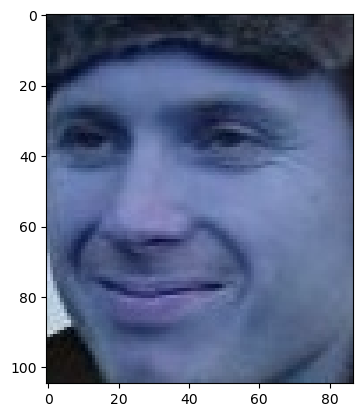

In [ ]:
plt.imshow(male1)

In [ ]:
male_image_names[1015]

'095921.jpg.jpg'

In [ ]:
path_male + male_image_names[1015]

'D:/DATASETS/Gender/Male/095921.jpg.jpg'

In [ ]:
cv2.imread(path_male + male_image_names[1015])

array([[[ 49,  89, 141],
        [ 51,  91, 144],
        [ 60, 101, 156],
        ...,
        [ 74,  46,  99],
        [ 74,  44,  97],
        [ 78,  44,  98]],

       [[ 50,  90, 142],
        [ 52,  94, 147],
        [ 62, 103, 158],
        ...,
        [ 74,  46,  99],
        [ 79,  49, 102],
        [ 75,  43,  97]],

       [[ 52,  95, 146],
        [ 58, 100, 153],
        [ 65, 106, 161],
        ...,
        [ 67,  42,  92],
        [ 78,  51, 101],
        [ 77,  48,  98]],

       ...,

       [[ 33,  80, 132],
        [ 30,  77, 129],
        [ 32,  79, 131],
        ...,
        [ 61,  30,  75],
        [ 60,  29,  74],
        [ 65,  32,  76]],

       [[ 46,  94, 146],
        [ 41,  89, 141],
        [ 40,  88, 140],
        ...,
        [ 61,  30,  75],
        [ 61,  30,  75],
        [ 64,  31,  75]],

       [[ 57, 105, 157],
        [ 51,  99, 151],
        [ 50,  98, 150],
        ...,
        [ 61,  30,  75],
        [ 63,  32,  77],
        [ 62,  29,  73]]

In [ ]:
male2 = cv2.imread(path_male + male_image_names[1015])

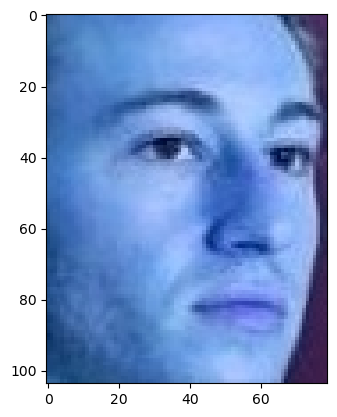

In [ ]:
plt.imshow(male2)

## Preprocessing: Build Feature & Label Arrays

In [ ]:
IMG_SIZE = 64

def load_images(path, label):
    data, labels = [], []
    for fname in os.listdir(path):
        img = cv2.imread(path + fname)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img / 255.0)
        labels.append(label)
    return data, labels

female_data, female_labels = load_images(path_female, 0)
male_data, male_labels = load_images(path_male, 1)

print('Female images:', len(female_data))
print('Male images:', len(male_data))

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X = np.array(female_data + male_data)
y = to_categorical(np.array(female_labels + male_labels), 2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

## Model Building & Training

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.1
)

## Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test Accuracy:', test_acc)
print('Test Loss:', test_loss)

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('CNN Training Accuracy')
plt.show()

## Results

* **Achieved strong binary classification performance** by training a CNN with convolutional and pooling layers on resized and normalized facial images.
* **OpenCV preprocessing improved input consistency** through image resizing, normalization, and standardized data preparation before model training.
* **Validated model generalization** using separate training and validation data, identifying opportunities for improvement through data augmentation and transfer learning.

